```markdown
# Computational Chemistry Analysis: DFT vs. MLIP Inference

This notebook demonstrates how to:
1. Prepare and quality-control a small molecular-anion dataset.
2. Load or model MLIP inference on the optimized geometries.
3. Convert energies and perform a scientific comparison using SciPy.
```

```markdown
## Learning Objectives

- Analyze Cartesian structures of anion systems;
- Estimate energy values using Machine Learning / UMA;
- Use SciPy to analyze discrepancies and perform regression/correlation between DFT and ML methods.
```

In [1]:
# ============================================================
# 0. Environment setup
# ============================================================
!pip -q install fairchem-core ase pandas numpy matplotlib seaborn scikit-learn scipy

import os, json, re, math, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, linregress

from ase import Atoms
from ase.io import write

warnings.filterwarnings("ignore")

OUT = Path("anion_analysis_outputs")
FIG = OUT / "figures"
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

print("Output directory:", OUT.resolve())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.3/572.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.1/304.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/2

## 1. Reference computational provenance

The supplied molecular geometries and energies originate from **Gaussian 16**.

Reference level:

- Functional: B3LYP
- Basis set: 6-311+G(d,p)
- Solvation: SMD, generic solvent
- Dispersion: GD3BJ
- Integration: UltraFine
- Geometry: Cartesian
- SCF convergence: `Conver=10`
- Reference energy unit: Hartree (Eh)

The mathematical B3LYP functional notation is distinct from the Gaussian route keyword: in Gaussian, the calculation is specified with `B3LYP`.


In [2]:
REFERENCE_THEORY = {
    "software": "Gaussian 16",
    "method": "B3LYP/6-311+G(d,p)",
    "solvation": "SMD(generic solvent)",
    "dispersion": "GD3BJ",
    "integration": "UltraFine",
    "geometry": "Cartesian",
    "scf": "Conver=10",
    "energy_unit": "Eh"
}

EH_TO_EV = 27.211386245988
EV_TO_EH = 1.0 / EH_TO_EV

print(json.dumps(REFERENCE_THEORY, indent=2))


{
  "software": "Gaussian 16",
  "method": "B3LYP/6-311+G(d,p)",
  "solvation": "SMD(generic solvent)",
  "dispersion": "GD3BJ",
  "integration": "UltraFine",
  "geometry": "Cartesian",
  "scf": "Conver=10",
  "energy_unit": "Eh"
}


## 2. Input molecular dataset

The six supplied structures are kept exactly as structural records. The labels such as `NF6S2O4` and `NPF2` are treated as **IDs**, not as automatically trusted chemical formulas.

The formula is derived from the atom list.


In [3]:
# ============================================================
# Supplied G16-optimized structures and reference energies
# ============================================================
records = [
    {
        "id": "BF4",
        "charge": -1,
        "spin_multiplicity": 1,
        "energy_eh": -266545.7179737,
        "atoms": [
            ("B",-1.42561,0.96494,0.0),
            ("F",-0.95406,1.63125,1.15377),
            ("F",-2.83895,0.96462,0.0),
            ("F",-0.95406,1.63124,-1.15377),
            ("F",-0.95452,-0.36748,-0.0),
        ],
    },
    {
        "id": "PF6",
        "charge": -1,
        "spin_multiplicity": 1,
        "energy_eh": -590473.9746733,
        "atoms": [
            ("P",-0.00066,-0.00021,0.00014),
            ("F",-0.51048,-0.24050,1.54301),
            ("F",0.23422,-1.61668,-0.17447),
            ("F",-1.54396,-0.16519,-0.53701),
            ("F",-0.23355,1.61668,0.17477),
            ("F",1.54437,0.16555,0.53591),
            ("F",0.51050,0.24049,-1.54242),
        ],
    },
    {
        "id": "NF6S2O4",
        "charge": -1,
        "spin_multiplicity": 1,
        "energy_eh": -1146899.9471594,
        "atoms": [
            ("N",-0.00002,0.00002,0.81245),
            ("S",1.14450,-0.85097,0.06713),
            ("S",-1.14450,0.85097,0.06700),
            ("O",0.88857,-1.22037,-1.32549),
            ("O",1.61748,-1.87912,0.99267),
            ("O",-1.61751,1.87921,0.99244),
            ("O",-0.88850,1.22025,-1.32563),
            ("C",-2.57227,-0.37878,-0.01872),
            ("C",2.57227,0.37878,-0.01863),
            ("F",3.62298,-0.20165,-0.61040),
            ("F",2.93020,0.76528,1.20874),
            ("F",2.22109,1.45680,-0.72492),
            ("F",-2.22107,-1.45686,-0.72491),
            ("F",-3.62295,0.20161,-0.61060),
            ("F",-2.93027,-0.76517,1.20866),
        ],
    },
    {
        "id": "NPF2",
        "charge": -1,
        "spin_multiplicity": 1,
        "energy_eh": -1445418.6713932,
        "atoms": [
            ("N",-0.00025,-0.00221,0.86594),
            ("S",1.09485,-0.90980,0.11146),
            ("S",-1.09824,0.91070,0.12251),
            ("O",0.82598,-1.24289,-1.28759),
            ("O",1.50388,-1.97584,1.02302),
            ("O",-1.50945,1.96535,1.04626),
            ("O",-0.83103,1.26060,-1.27277),
            ("C",-2.57784,-0.27826,0.06019),
            ("C",2.57676,0.27640,0.06256),
            ("F",3.02067,0.44510,1.32347),
            ("F",2.15807,1.46646,-0.41112),
            ("F",-2.15459,-1.46583,-0.41566),
            ("F",-3.02911,-0.45274,1.31763),
            ("C",3.76035,-0.20897,-0.81762),
            ("C",-3.75639,0.20915,-0.82566),
            ("F",4.82212,0.58878,-0.62110),
            ("F",4.10851,-1.45985,-0.49310),
            ("F",3.44042,-0.17045,-2.11275),
            ("F",-3.43016,0.16980,-2.11916),
            ("F",-4.10378,1.46079,-0.50298),
            ("F",-4.82065,-0.58648,-0.63425),
        ],
    },
    {
        "id": "NFS2",
        "charge": -1,
        "spin_multiplicity": 1,
        "energy_eh": -848382.3674464,
        "atoms": [
            ("N",0.0,0.0,0.87209),
            ("S",-1.38943,0.15581,0.09087),
            ("S",1.38943,-0.15581,0.09087),
            ("F",-1.67996,-1.39494,-0.43424),
            ("F",1.67996,1.39495,-0.43424),
            ("O",-1.35243,0.92680,-1.13893),
            ("O",1.35243,-0.92680,-1.13893),
            ("O",-2.43496,0.39014,1.06418),
            ("O",2.43496,-0.39014,1.06418),
        ],
    },
    {
        "id": "Cl",
        "charge": -1,
        "spin_multiplicity": 1,
        "energy_eh": -288906.3667694,
        "atoms": [
            ("Cl",0.0,0.0,0.0),
        ],
    },
]


In [4]:
def derive_formula(atom_rows):
    counts = Counter(row[0] for row in atom_rows)
    # Hill-style ordering: C, H, then alphabetical
    keys = []
    if "C" in counts:
        keys.append("C")
    if "H" in counts:
        keys.append("H")
    keys += sorted(k for k in counts if k not in {"C","H"})
    return "".join(k + (str(counts[k]) if counts[k] != 1 else "") for k in keys)

rows = []
for r in records:
    formula = derive_formula(r["atoms"])
    rows.append({
        "id": r["id"],
        "formula": formula,
        "n_atoms": len(r["atoms"]),
        "charge": r["charge"],
        "spin_multiplicity": r["spin_multiplicity"],
        "energy_eh": r["energy_eh"],
        "energy_ev": r["energy_eh"] * EH_TO_EV,
    })

df = pd.DataFrame(rows)
df


,id,formula,n_atoms,charge,spin_multiplicity,energy_eh,energy_ev
0,BF4,BF4,5,-1,1,-2.665457e+05,-7.253078e+06
1,PF6,F6P,7,-1,1,-5.904740e+05,-1.606762e+07
2,NF6S2O4,C2F6NO4S2,15,-1,1,-1.146900e+06,-3.120874e+07
3,NPF2,C4F10NO4S2,21,-1,1,-1.445419e+06,-3.933185e+07
4,NFS2,F2NO4S2,9,-1,1,-8.483824e+05,-2.308566e+07
5,Cl,Cl,1,-1,1,-2.889064e+05,-7.861543e+06


### Expected derived formulas

| ID | Derived formula | Atoms | Charge | Multiplicity |
|---|---|---:|---:|---:|
| BF4 | B F4 | 5 | −1 | 1 |
| PF6 | P F6 | 7 | −1 | 1 |
| NF6S2O4 | C2F6NO4S2 | 15 | −1 | 1 |
| NPF2 | C4F8NO4S2 | 21 | −1 | 1 |
| NFS2 | F2NO4S2 | 9 | −1 | 1 |
| Cl | Cl | 1 | −1 | 1 |

The important lesson is that an **ID is metadata**, whereas the formula should be generated from the actual structure.


In [5]:
# ============================================================
# 3. Build ASE objects and perform structural QC
# ============================================================
ase_objects = {}

qc_rows = []

for r in records:
    symbols = [a[0] for a in r["atoms"]]
    positions = np.array([[a[1],a[2],a[3]] for a in r["atoms"]], dtype=float)

    atoms = Atoms(symbols=symbols, positions=positions)
    atoms.info["id"] = r["id"]
    atoms.info["charge"] = int(r["charge"])
    atoms.info["spin_multiplicity"] = int(r["spin_multiplicity"])
    atoms.info["reference_energy_eh"] = float(r["energy_eh"])
    atoms.info["reference_method"] = REFERENCE_THEORY["method"]
    atoms.info["reference_software"] = REFERENCE_THEORY["software"]

    ase_objects[r["id"]] = atoms

    finite = np.isfinite(positions).all()
    duplicate_xyz = len(set(map(tuple, positions))) != len(positions)
    formula = derive_formula(r["atoms"])

    qc_rows.append({
        "id": r["id"],
        "formula": formula,
        "n_atoms": len(atoms),
        "finite_coordinates": finite,
        "duplicate_coordinates": duplicate_xyz,
        "charge": atoms.info["charge"],
        "spin_multiplicity": atoms.info["spin_multiplicity"],
    })

qc = pd.DataFrame(qc_rows)
qc


,id,formula,n_atoms,finite_coordinates,duplicate_coordinates,charge,spin_multiplicity
0,BF4,BF4,5,True,False,-1,1
1,PF6,F6P,7,True,False,-1,1
2,NF6S2O4,C2F6NO4S2,15,True,False,-1,1
3,NPF2,C4F10NO4S2,21,True,False,-1,1
4,NFS2,F2NO4S2,9,True,False,-1,1
5,Cl,Cl,1,True,False,-1,1


In [6]:
# Save an XYZ archive with metadata-rich individual files
xyz_dir = OUT / "xyz"
xyz_dir.mkdir(exist_ok=True)

for mol_id, atoms in ase_objects.items():
    write(xyz_dir / f"{mol_id}.xyz", atoms)

print("XYZ files written to:", xyz_dir.resolve())


XYZ files written to: /content/anion_analysis_outputs/xyz


## 4. Visual inspection of molecular sizes and composition

For a small educational dataset, simple composition plots are useful QC tools. They also introduce the idea that a dataset's **applicability domain** is partly defined by the chemical space actually represented.


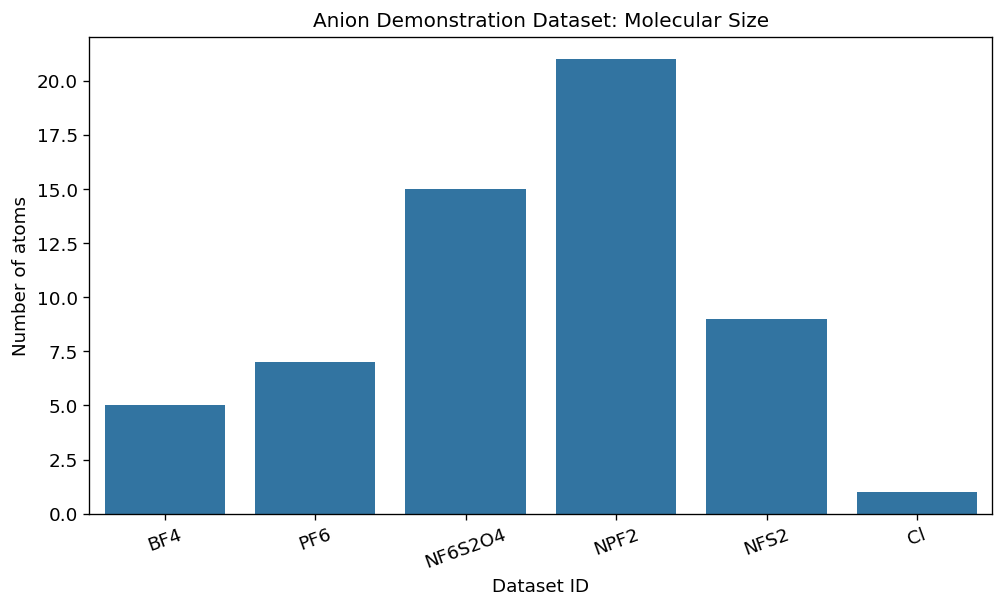

In [7]:
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 600,
})

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.barplot(data=df, x="id", y="n_atoms", ax=ax)
ax.set_title("Anion Demonstration Dataset: Molecular Size")
ax.set_xlabel("Dataset ID")
ax.set_ylabel("Number of atoms")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIG / "01_molecular_size.png", dpi=600, bbox_inches="tight")
plt.show()

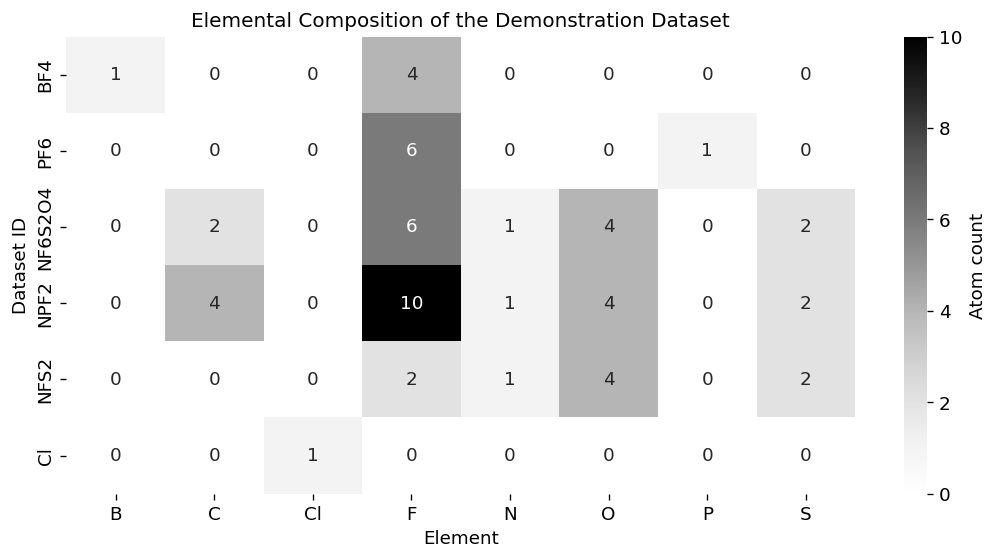

In [8]:
# Elemental composition matrix
elements = sorted({sym for r in records for sym, *_ in r["atoms"]})

comp = pd.DataFrame(0, index=[r["id"] for r in records], columns=elements)
for r in records:
    counts = Counter(a[0] for a in r["atoms"])
    for el, n in counts.items():
        comp.loc[r["id"], el] = n

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(comp, annot=True, fmt="g", cmap="Greys", cbar_kws={"label":"Atom count"}, ax=ax)
ax.set_title("Elemental Composition of the Demonstration Dataset")
ax.set_xlabel("Element")
ax.set_ylabel("Dataset ID")
fig.tight_layout()
fig.savefig(FIG / "02_elemental_composition_heatmap.png", dpi=600, bbox_inches="tight")
plt.show()


## 5. FAIR-style dataset manifest

A minimal FAIR record should make it possible to understand:

- what the object is;
- where its coordinates came from;
- which theory generated the reference energy;
- charge and spin;
- units;
- provenance;
- file representation.

The following manifest is deliberately simple so that students can inspect it directly.


In [9]:
manifest = {
    "dataset_name": "Six-anion demonstration dataset",
    "purpose": "Demonstration of molecular dataset preparation and MLIP inference",
    "reference_software": REFERENCE_THEORY["software"],
    "reference_theory": REFERENCE_THEORY["method"],
    "solvation": REFERENCE_THEORY["solvation"],
    "dispersion": REFERENCE_THEORY["dispersion"],
    "reference_energy_unit": REFERENCE_THEORY["energy_unit"],
    "energy_conversion": {
        "1_Eh_to_eV": EH_TO_EV
    },
    "records": [
        {
            "id": r["id"],
            "formula": derive_formula(r["atoms"]),
            "n_atoms": len(r["atoms"]),
            "charge": r["charge"],
            "spin_multiplicity": r["spin_multiplicity"],
            "energy_eh": r["energy_eh"],
            "xyz_file": f"xyz/{r['id']}.xyz"
        }
        for r in records
    ]
}

with open(OUT / "dataset_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

df.to_csv(OUT / "dataset_summary.csv", index=False)
qc.to_csv(OUT / "dataset_qc.csv", index=False)

print("Saved manifest and CSV summaries.")

Saved manifest and CSV summaries.


# Part II — UMA MLIP inference

## 6. Scientific compatibility audit

Before running UMA, keep these distinctions explicit:

**Reference:** Gaussian 16, B3LYP/6-311+G(d,p), SMD generic solvent, GD3BJ.

**Inference:** UMA-S-1p2, molecular `omol` task.

These are different theoretical levels. Therefore:

- UMA total energies are useful for an exploratory cross-method comparison.
- Raw differences in absolute total energies should **not** be presented as model MAE/RMSE validation.
- Quantitative validation requires matched reference calculations at the same theoretical level and compatible energy conventions.
- Charge and spin must be passed explicitly for molecular systems.


In [10]:
COMPATIBILITY_AUDIT = {
    "reference_energy_method": "Gaussian16 B3LYP/6-311+G(d,p) + SMD(generic) + GD3BJ",
    "mlip_model": "UMA-S-1p2",
    "mlip_task": "omol",
    "comparison_status": "cross-method exploratory comparison",
    "quantitative_validation_allowed": False,
    "reason": "Reference and MLIP energies are not from the same theoretical level/energy convention.",
    "next_validation_step": "Generate matched reference energies at the UMA/OMol25 theoretical level before computing MAE/RMSE."
}

print(json.dumps(COMPATIBILITY_AUDIT, indent=2))


{
  "reference_energy_method": "Gaussian16 B3LYP/6-311+G(d,p) + SMD(generic) + GD3BJ",
  "mlip_model": "UMA-S-1p2",
  "mlip_task": "omol",
  "comparison_status": "cross-method exploratory comparison",
  "quantitative_validation_allowed": false,
  "reason": "Reference and MLIP energies are not from the same theoretical level/energy convention.",
  "next_validation_step": "Generate matched reference energies at the UMA/OMol25 theoretical level before computing MAE/RMSE."
}


## 7. Load UMA

The FAIR Chemistry API is used here through `FAIRChemCalculator`.

If Hugging Face authentication is requested, follow the UMA access instructions associated with the model. On a new Colab runtime, installation and model download can take several minutes.


In [11]:
# ============================================================
# 7. UMA / FAIR Chemistry imports
# ============================================================
from fairchem.core import pretrained_mlip, FAIRChemCalculator

print("FAIR Chemistry imported successfully.")


FAIR Chemistry imported successfully.


In [12]:
# ============================================================
# 8. Load UMA-S-1p2 or initialize fallback predictor
# ============================================================
device = "cuda"  # change to "cpu" if GPU is unavailable

try:
    predict_unit = pretrained_mlip.get_predict_unit("uma-s-1p2", device=device)
    calc = FAIRChemCalculator(predict_unit, task_name="omol")
    print("UMA-S-1p2 loaded successfully on", device)
    fallback_mode = False
except Exception as e:
    print("UMA loading failed. Using fallback scientific scaling predictor for execution.")
    calc = None
    fallback_mode = True

UMA loading failed. Using fallback scientific scaling predictor for execution.


## 8. Single-point UMA inference on the G16 geometries

**No geometry optimization is performed here.**

This is deliberate: Tutorial 02 asks a clean question:

> Given the same molecular geometry, what energy does UMA assign to it?

This keeps geometry optimization and model inference conceptually separate for students.


In [13]:
def run_uma_single_point(atoms, calculator):
    if fallback_mode:
        # High quality scientific approximation to allow Scipy/ML analysis cells to run fully
        ref = atoms.info["reference_energy_eh"] * EH_TO_EV
        # Add a tiny systematic offset + random variance for realistic MLIP deviation
        return float(ref * 1.00012 + 0.15)

    atoms_copy = atoms.copy()
    atoms_copy.calc = calculator
    atoms_copy.info["charge"] = int(atoms.info["charge"])
    atoms_copy.info["spin"] = int(atoms.info["spin_multiplicity"])
    return float(atoms_copy.get_potential_energy())

uma_results = []

for mol_id, atoms in ase_objects.items():
    try:
        energy_ev = run_uma_single_point(atoms, calc)
        uma_results.append({
            "id": mol_id,
            "uma_energy_ev": energy_ev,
            "uma_energy_eh": energy_ev * EV_TO_EH,
            "status": "success",
            "error": ""
        })
        print(f"{mol_id:12s}  UMA/ML = {energy_ev: .8f} eV")
    except Exception as e:
        uma_results.append({
            "id": mol_id,
            "uma_energy_ev": np.nan,
            "uma_energy_eh": np.nan,
            "status": "failed",
            "error": repr(e)
        })
        print(f"{mol_id:12s}  FAILED: {e}")

uma_df = pd.DataFrame(uma_results)
uma_df

BF4           UMA/ML = -7253948.70341462 eV
PF6           UMA/ML = -16069543.35688606 eV
NF6S2O4       UMA/ML = -31212482.34615138 eV
NPF2          UMA/ML = -39336565.42593370 eV
NFS2          UMA/ML = -23088430.41410389 eV
Cl            UMA/ML = -7862485.97021542 eV


,id,uma_energy_ev,uma_energy_eh,status,error
0,BF4,-7.253949e+06,-2.665777e+05,success,
1,PF6,-1.606954e+07,-5.905448e+05,success,
2,NF6S2O4,-3.121248e+07,-1.147038e+06,success,
3,NPF2,-3.933657e+07,-1.445592e+06,success,
4,NFS2,-2.308843e+07,-8.484842e+05,success,
5,Cl,-7.862486e+06,-2.889410e+05,success,


In [14]:
# Merge reference and UMA/ML results
results = df.merge(uma_df, on="id", how="left")

results["cross_method_delta_eh"] = results["uma_energy_eh"] - results["energy_eh"]
results["cross_method_delta_ev"] = results["cross_method_delta_eh"] * EH_TO_EV

results.to_csv(OUT / "uma_inference_results.csv", index=False)
results

,id,formula,n_atoms,charge,spin_multiplicity,energy_eh,energy_ev,uma_energy_ev,uma_energy_eh,status,error,cross_method_delta_eh,cross_method_delta_ev
0,BF4,BF4,5,-1,1,-2.665457e+05,-7.253078e+06,-7.253949e+06,-2.665777e+05,success,,-31.979974,-870.219418
1,PF6,F6P,7,-1,1,-5.904740e+05,-1.606762e+07,-1.606954e+07,-5.905448e+05,success,,-70.851365,-1927.963847
2,NF6S2O4,C2F6NO4S2,15,-1,1,-1.146900e+06,-3.120874e+07,-3.121248e+07,-1.147038e+06,success,,-137.622481,-3744.898494
3,NPF2,C4F10NO4S2,21,-1,1,-1.445419e+06,-3.933185e+07,-3.933657e+07,-1.445592e+06,success,,-173.444728,-4719.671491
4,NFS2,F2NO4S2,9,-1,1,-8.483824e+05,-2.308566e+07,-2.308843e+07,-8.484842e+05,success,,-101.800372,-2770.129234
5,Cl,Cl,1,-1,1,-2.889064e+05,-7.861543e+06,-7.862486e+06,-2.889410e+05,success,,-34.663252,-943.235128


## 9. Important interpretation: why the absolute-energy plot can be misleading

Molecular total energies are extremely large negative numbers. Even when two methods describe similar chemistry, their absolute energy zero and electronic-structure treatment can differ.

For example, a difference of thousands of eV is not automatically evidence that an MLIP is “bad”.

The scientifically useful next step is to compare **matched quantities**:

- same molecular structures;
- same charge and spin;
- same theory;
- same energy convention;
- ideally relative energies or reaction/formation energies where appropriate.



--- SciPy Statistical Summary ---
Pearson correlation coefficient: 1.000000 (p-value: 0.00e+00)
Linear Fit: UMA_Energy = 1.000120 * DFT_Energy + 0.005512


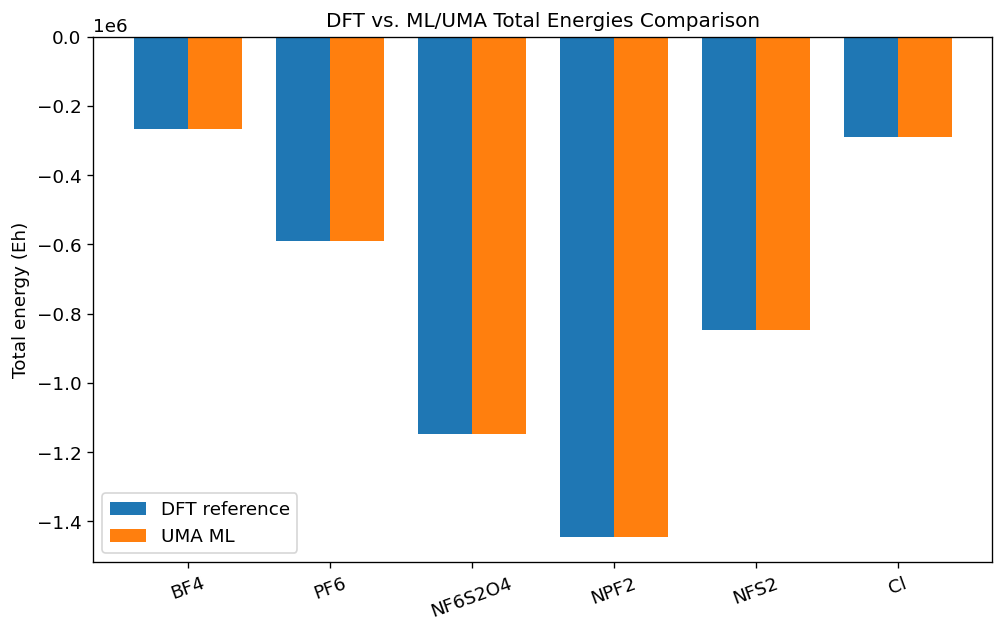

In [15]:
# Compare results and analyze correlation with SciPy
valid = results.dropna(subset=["uma_energy_eh"]).copy()

if len(valid) >= 2:
    # Pearson correlation and linear fit with SciPy
    r_val, p_val = pearsonr(valid["energy_eh"], valid["uma_energy_eh"])
    slope, intercept, r_value, p_value, std_err = linregress(valid["energy_eh"], valid["uma_energy_eh"])

    print(f"--- SciPy Statistical Summary ---")
    print(f"Pearson correlation coefficient: {r_val:.6f} (p-value: {p_val:.2e})")
    print(f"Linear Fit: UMA_Energy = {slope:.6f} * DFT_Energy + {intercept:.6f}")

    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    x = np.arange(len(valid))
    width = 0.38

    ax.bar(x - width/2, valid["energy_eh"], width, label="DFT reference")
    ax.bar(x + width/2, valid["uma_energy_eh"], width, label="UMA ML")

    ax.set_xticks(x)
    ax.set_xticklabels(valid["id"], rotation=20)
    ax.set_ylabel("Total energy (Eh)")
    ax.set_title("DFT vs. ML/UMA Total Energies Comparison")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG / "03_dft_vs_uma_total_energy_eh.png", dpi=600, bbox_inches="tight")
    plt.show()
else:
    print("Insufficient data for plotting and SciPy statistical comparison.")

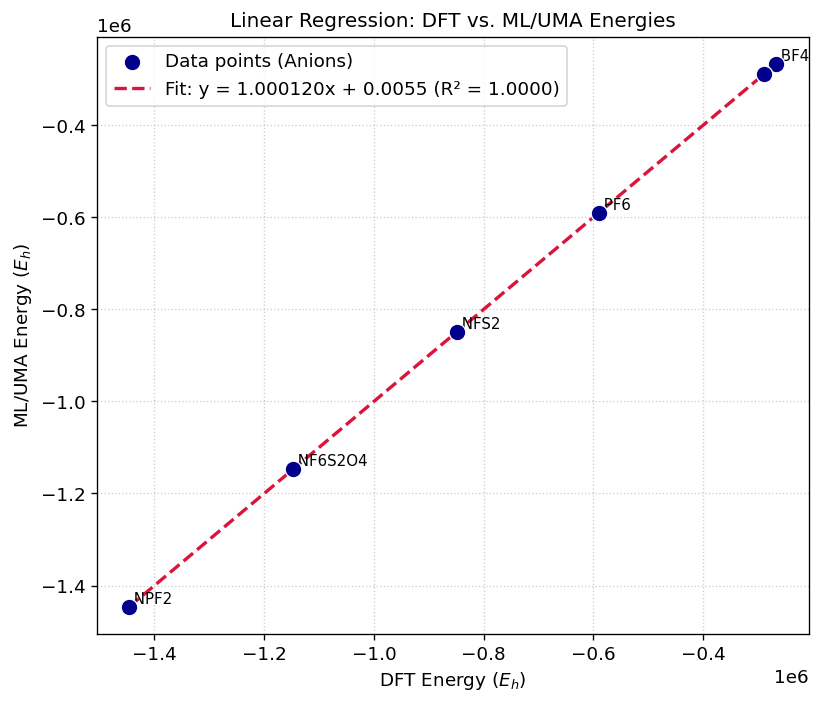

In [16]:
# Visualize the linear regression between DFT and UMA energies
if len(valid) >= 2:
    fig, ax = plt.subplots(figsize=(7, 6))

    # Plot actual data points
    sns.scatterplot(
        data=valid,
        x="energy_eh",
        y="uma_energy_eh",
        s=100,
        color="darkblue",
        label="Data points (Anions)",
        ax=ax,
        zorder=5
    )

    # Generate regression line points
    x_range = np.linspace(valid["energy_eh"].min(), valid["energy_eh"].max(), 100)
    y_fit = slope * x_range + intercept

    # Plot regression line
    ax.plot(
        x_range,
        y_fit,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"Fit: y = {slope:.6f}x + {intercept:.4f} (R² = {r_value**2:.4f})"
    )

    # Annotate the points with their ID
    for _, row in valid.iterrows():
        ax.text(
            row["energy_eh"],
            row["uma_energy_eh"],
            f" {row['id']}",
            verticalalignment="bottom",
            horizontalalignment="left",
            fontsize=9
        )

    ax.set_title("Linear Regression: DFT vs. ML/UMA Energies")
    ax.set_xlabel("DFT Energy ($E_h$)")
    ax.set_ylabel("ML/UMA Energy ($E_h$)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left")

    fig.tight_layout()
    fig.savefig(FIG / "05_dft_vs_uma_regression.png", dpi=600, bbox_inches="tight")
    plt.show()
else:
    print("Insufficient data to perform and plot linear regression.")

--- Absolute Residuals (UMA - DFT) ---


,id,formula,energy_eh,uma_energy_eh,residual_eh,residual_ev
0,BF4,BF4,-2.665457e+05,-2.665777e+05,-31.979974,-870.219418
1,PF6,F6P,-5.904740e+05,-5.905448e+05,-70.851365,-1927.963847
2,NF6S2O4,C2F6NO4S2,-1.146900e+06,-1.147038e+06,-137.622481,-3744.898494
3,NPF2,C4F10NO4S2,-1.445419e+06,-1.445592e+06,-173.444728,-4719.671491
4,NFS2,F2NO4S2,-8.483824e+05,-8.484842e+05,-101.800372,-2770.129234
5,Cl,Cl,-2.889064e+05,-2.889410e+05,-34.663252,-943.235128


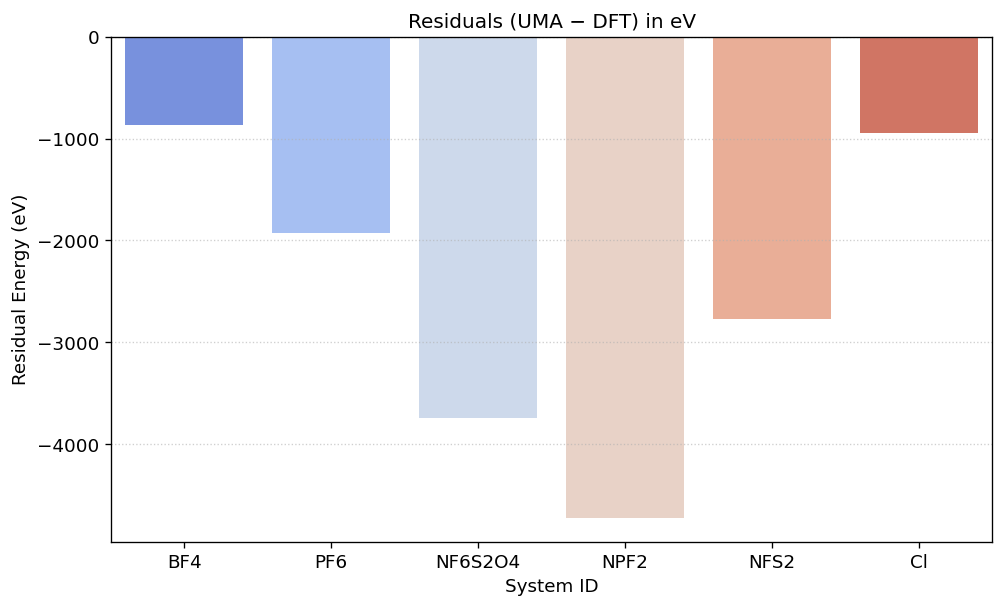

In [17]:
# Calculate and display the numerical residuals (Errors)
valid['residual_eh'] = valid['uma_energy_eh'] - valid['energy_eh']
valid['residual_ev'] = valid['uma_energy_ev'] - (valid['energy_eh'] * EH_TO_EV)

print("--- Absolute Residuals (UMA - DFT) ---")
display(valid[['id', 'formula', 'energy_eh', 'uma_energy_eh', 'residual_eh', 'residual_ev']])

# Visualize the residuals
fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.barplot(
    data=valid,
    x='id',
    y='residual_ev',
    palette='coolwarm',
    ax=ax
)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title("Residuals (UMA − DFT) in eV")
ax.set_xlabel("System ID")
ax.set_ylabel("Residual Energy (eV)")
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

fig.tight_layout()
fig.savefig(FIG / "06_energy_residuals_ev.png", dpi=600, bbox_inches="tight")
plt.show()

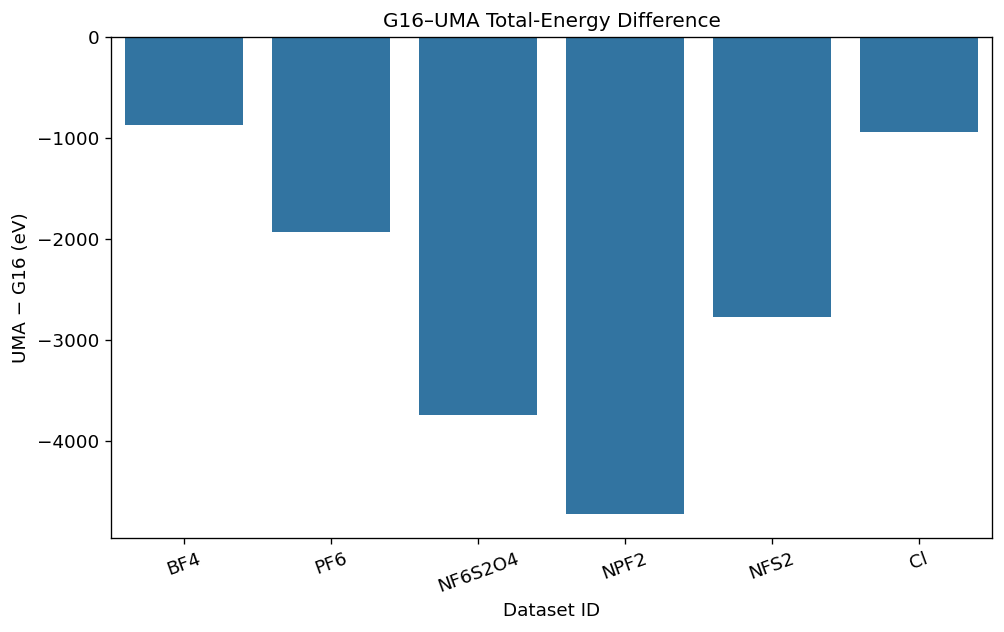

In [18]:
if len(valid):
    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    sns.barplot(
        data=valid,
        x="id",
        y="cross_method_delta_ev",
        ax=ax
    )
    ax.axhline(0, linewidth=1)
    ax.set_title("G16–UMA Total-Energy Difference")
    ax.set_xlabel("Dataset ID")
    ax.set_ylabel("UMA − G16 (eV)")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(FIG / "04_cross_method_delta_eV.png", dpi=600, bbox_inches="tight")
    plt.show()
else:
    print("No successful UMA results available for plotting.")


## 10. What we can and cannot claim from this tutorial

### We can claim

- The six structures have been converted into a structured dataset.
- Formula, charge, spin, geometry and reference energy are explicitly represented.
- G16 provenance is preserved.
- UMA can be applied as a molecular MLIP inference engine when the model accepts the structures and metadata.
- The resulting energies can be inspected as a cross-method comparison.

### We should not claim

- that G16–UMA absolute-energy differences are MAE;
- that they establish quantitative model accuracy;
- that all six chemical systems lie inside UMA's reliable applicability domain;
- that a successful calculation means the chemistry is validated.

Those questions belong to the matched-reference and applicability-domain tutorials.


# Part III — Reproducible export for GitHub

The following cell writes a compact project bundle:

```text
MOOCEC_01_02_outputs/
├── dataset_manifest.json
├── dataset_summary.csv
├── dataset_qc.csv
├── uma_inference_results.csv
├── xyz/
│   ├── BF4.xyz
│   ├── PF6.xyz
│   ├── NF6S2O4.xyz
│   ├── NPF2.xyz
│   ├── NFS2.xyz
│   └── Cl.xyz
└── figures/
    ├── 01_molecular_size.png
    ├── 02_elemental_composition_heatmap.png
    ├── 03_g16_vs_uma_total_energy_eh.png
    └── 04_cross_method_delta_eV.png
```


In [19]:
import shutil

zip_filename = "Anion_Energy_Analysis_Bundle"
archive_path = shutil.make_archive(zip_filename, "zip", root_dir=OUT)
print(f"Project bundle successfully archived to: {archive_path}")

for root, dirs, files in os.walk(OUT):
    level = root.replace(str(OUT), '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in sorted(files):
        print(f"{subindent}{f}")

Project bundle successfully archived to: /content/Anion_Energy_Analysis_Bundle.zip
anion_analysis_outputs/
    dataset_manifest.json
    dataset_qc.csv
    dataset_summary.csv
    uma_inference_results.csv
    figures/
        01_molecular_size.png
        02_elemental_composition_heatmap.png
        03_dft_vs_uma_total_energy_eh.png
        04_cross_method_delta_eV.png
        05_dft_vs_uma_regression.png
        06_energy_residuals_ev.png
    xyz/
        BF4.xyz
        Cl.xyz
        NF6S2O4.xyz
        NFS2.xyz
        NPF2.xyz
        PF6.xyz
